In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

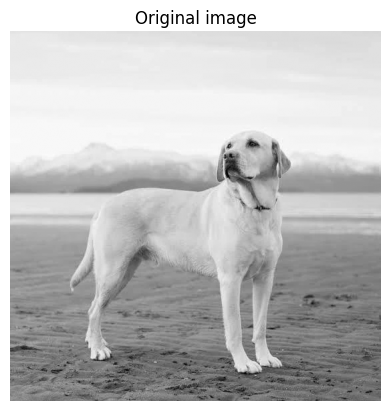

In [5]:
image = np.array(Image.open("Grey_image.png").convert("L"), dtype=np.float64)

plt.imshow(image, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

In [6]:
print("Image shape:", image.shape)
print("Some pixel values:\n", image[:5, :5])

Image shape: (553, 555)
Some pixel values:
 [[228. 228. 228. 228. 228.]
 [228. 228. 228. 228. 228.]
 [228. 228. 228. 228. 228.]
 [228. 228. 228. 228. 228.]
 [232. 232. 232. 232. 232.]]


In [7]:
def convolution(image, kernel):
    img_h, img_w = image.shape
    k_size = kernel.shape[0]
    pad = k_size // 2
    padded = np.pad(image, pad, mode="constant", constant_values=0)
    output = np.zeros_like(image)

    for i in range(img_h):
        for j in range(img_w):
            patch = padded[i:i+k_size, j:j+k_size]
            output[i, j] = np.sum(patch * kernel)

    return output

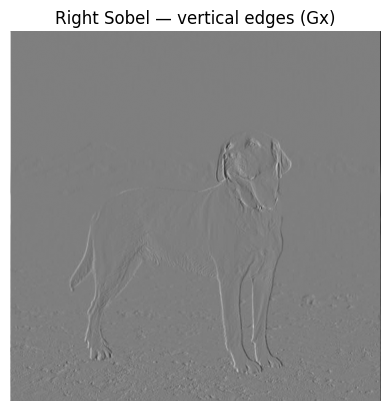

In [8]:
right_sobel = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])

Gx = convolution(image, right_sobel)

plt.imshow(Gx, cmap="gray")
plt.title("Right Sobel — vertical edges (Gx)")
plt.axis("off")
plt.show()

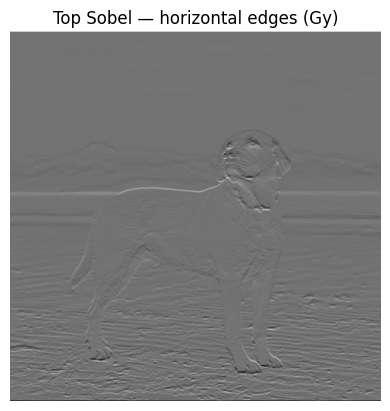

In [9]:
top_sobel = np.array([[-1, -2, -1],
                       [ 0,  0,  0],
                       [ 1,  2,  1]])

Gy = convolution(image, top_sobel)

plt.imshow(Gy, cmap="gray")
plt.title("Top Sobel — horizontal edges (Gy)")
plt.axis("off")
plt.show()

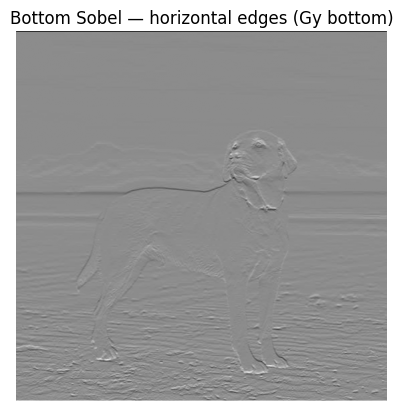

In [10]:
bottom_sobel = np.array([[ 1,  2,  1],
                          [ 0,  0,  0],
                          [-1, -2, -1]])

Gy_bottom = convolution(image, bottom_sobel)

plt.imshow(Gy_bottom, cmap="gray")
plt.title("Bottom Sobel — horizontal edges (Gy bottom)")
plt.axis("off")
plt.show()

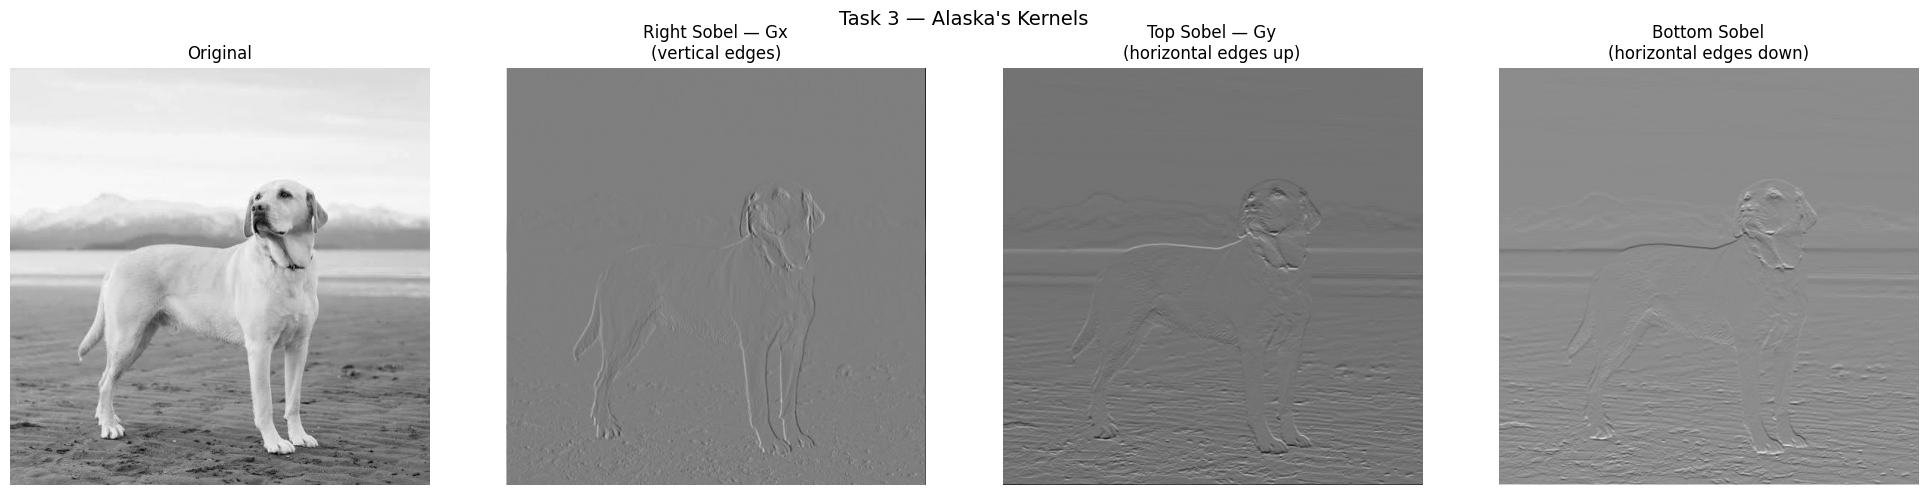

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(Gx, cmap="gray")
axes[1].set_title("Right Sobel — Gx\n(vertical edges)")
axes[1].axis("off")

axes[2].imshow(Gy, cmap="gray")
axes[2].set_title("Top Sobel — Gy\n(horizontal edges up)")
axes[2].axis("off")

axes[3].imshow(Gy_bottom, cmap="gray")
axes[3].set_title("Bottom Sobel\n(horizontal edges down)")
axes[3].axis("off")

plt.suptitle("Task 3 — Alaska's Kernels", fontsize=14)
plt.tight_layout()
plt.show()